# Import libraries

In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import argparse

import sys
sys.path.append("..")
from ml_solver import MLSolver, DeepONet, FNOforPDE
from data_generation import GaussianRandomField, PDEDataset2
from pde import PoissonEquation1D, PoissonEquation2D, HelmholtzEquation1D, HelmholtzEquation2D
from numerical_solver import WeightedJacobiSolver, MultigridSolver, GaussSeidelSolver
from hybrid_solver import Router, ConstantRouter, HINTSRouter, LSTMGreedyRouter, HybridSolver


from trainer import Trainer, EarlyStopping, ApproxGreedyRouterLoss, ScheduledSampler
import json
import latextable
import pickle
import pandas as pd
from texttable import Texttable

# Function to test any given hybrid solver

In [3]:
def test_model(model, dataloader, in_channels, dim, loss = ApproxGreedyRouterLoss(), centered = True, loss_t = False):
    model.eval()
    errors_greedy = ()
    loss_greedy = () if loss_t else None
    residuals = ()
    mode_1_errors = ()
    mode_5_errors = ()
    mode_10_errors = ()
    with torch.no_grad():
        for batch in dataloader:
            model.reset()
            input, output = batch
            bs = input.shape[0]
            # f = input[:, 0, :].reshape(bs, -1)
            # if in_channels > 1:
            #     a = input[:, 1, :].reshape(bs, -1)
            # else:
            #     a = None
            f = input[:, -1, :].reshape(bs, -1)
            if model.equation.equation == "Poisson":
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
                k2 = None
            else:
                k2 = input[:, -2, :].reshape(bs, -1)
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
            pred = model(f = f, a = a, k2 = k2, u0=None, return_dict = True, training=loss, ground_truth = output.reshape(bs, -1))
            if centered:
                predictions = pred["predictions"] - torch.mean(pred["predictions"], axis = 2, keepdim = True)
            else:
                predictions =  pred["predictions"] 
            initial_prediction = torch.zeros_like(predictions[0]).unsqueeze(0)
            predictions = torch.cat((initial_prediction, predictions), dim = 0)
            # initial_error = torch.norm()
            error = torch.norm(predictions - output.reshape(bs, -1).unsqueeze(0), dim=2).detach().cpu().numpy()
            residual = torch.norm(pred["residuals"], dim = 2).detach().cpu().numpy()
            residuals += (residual, )
            errors_greedy += (error,)
            if loss_t:
                loss_greedy += (loss(pred, output.reshape(bs, -1), "none").detach().cpu().numpy(), )
            error = (predictions - output.reshape(bs, -1).unsqueeze(0)).detach().cpu().numpy()
                        
            if dim == 1:
                mode_wise_error = np.fft.rfftn(error, axes = [-1])
                mode_1_error = mode_wise_error[:, :, 1]
                mode_1_norm = np.sqrt(mode_1_error.real**2 + mode_1_error.imag**2)
                mode_5_error = mode_wise_error[:, :, 5]
                mode_5_norm = np.sqrt(mode_5_error.real**2 + mode_5_error.imag**2)

                mode_10_error = mode_wise_error[:, :, 10]
                mode_10_norm = np.sqrt(mode_10_error.real**2 + mode_10_error.imag**2)

            else:
                N = int(np.sqrt(error.shape[2]))
                error = error.reshape(error.shape[0], error.shape[1], N, N)
                mode_wise_error = np.fft.rfftn(error, axes = [-2,-1])
                mode_1_error = mode_wise_error[:, :, 1, 1]
                mode_1_norm = np.sqrt(mode_1_error.real**2 + mode_1_error.imag**2)
                mode_5_error = mode_wise_error[:, :, 5, 5]
                mode_5_norm = np.sqrt(mode_5_error.real**2 + mode_5_error.imag**2)

                mode_10_error = mode_wise_error[:, :, 10, 10]
                mode_10_norm = np.sqrt(mode_10_error.real**2 + mode_10_error.imag**2)
            mode_1_errors += (mode_1_norm,)
            mode_5_errors += (mode_5_norm,)
            mode_10_errors += (mode_10_norm,)

    errors_greedy = np.concatenate(errors_greedy, axis = 1)
    loss_greedy = np.concatenate(loss_greedy) if loss_t else None
    residuals = np.concatenate(residuals, axis = 1)
    mode_1_errors = np.concatenate(mode_1_errors, axis = 1)
    mode_5_errors = np.concatenate(mode_5_errors, axis = 1)
    mode_10_errors = np.concatenate(mode_10_errors, axis = 1)
    return errors_greedy, loss_greedy, residuals, mode_1_errors, mode_5_errors, mode_10_errors


# Function to test the true greedy hybrid solver

In [4]:
def true_greedy_model(model_hints, test_loader):
    errors_true_greedy = ()
    loss_true_greedy = ()
    with torch.no_grad():
        for batch in test_loader:
            model_hints.reset()
            input, output = batch
            bs = input.shape[0]
            f = input[:, -1, :].reshape(bs, -1)
            if model_hints.equation.equation == "Poisson":
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
                k2 = None
            else:
                k2 = input[:, -2, :].reshape(bs, -1)
                if in_channels > 1:
                    a = input[:, 0, :].reshape(bs, -1)
                else:
                    a = None
            
            pred = model_hints(f = f, a = a, k2=k2, u0=None, return_dict = True, training=True, teacher_forcing = 1.0, ground_truth = output.reshape(bs, -1))
            if model_hints.equation.equation == "Poisson" and model_hints.equation.boundary == "Periodic":
                expert_predictions = pred["complete_expert_predictions"] - torch.mean(pred["complete_expert_predictions"], dim=-1, keepdim=True)
            else:
                expert_predictions = pred["complete_expert_predictions"]
            print(expert_predictions.shape)
            errors_expert = torch.norm(expert_predictions - output.reshape(bs, -1).unsqueeze(0), dim=-1)
            best_solver = torch.argmin(errors_expert, dim=1)
            scores = torch.zeros(arguments["max_iters"], input.shape[0], 2, device = device)
            scores = torch.nn.functional.one_hot(best_solver, num_classes=2).to(scores.dtype)
            pred["routing_scores"] = scores 
            
            loss_true_greedy += (loss(pred, output.reshape(bs, -1), "none").detach().cpu().numpy(), )
            initial_prediction = torch.zeros_like(expert_predictions[0]).unsqueeze(0)
            expert_predictions = torch.cat((initial_prediction, expert_predictions), dim = 0)
            errors_expert = torch.norm(expert_predictions - output.reshape(bs, -1).unsqueeze(0), dim=-1)
            best_error = torch.min(errors_expert, dim=1).values.detach().cpu().numpy()
            errors_true_greedy += (best_error,)
    errors_true_greedy = np.concatenate(errors_true_greedy, axis=1)
    loss_true_greedy = np.concatenate(loss_true_greedy)
    return errors_true_greedy, best_solver

# Set the parameters

In [5]:
ml_model_type = "deeponet"
ml_model_name = "msealphaepsilon_loss_new_data4"
model_type = "lstm"
model_name = "trying_something"
equation = "Poisson"
boundary = "Dirichlet"
dim = 1
in_channels = 1
ckp_dir = f"/nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints"
solvers = "jacobi" # "jacobi_0.5,jacobi_0.67,jacobi_0.75,jacobi_0.8,jacobi"#,jacobi,jacobi_0.8"
n_samples = 8

# Load the ML solver arguments and Router arguments

In [7]:
ml_ckp_path = ckp_dir + f"/{ml_model_type}_{ml_model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_best.pth"
ml_args_path = ckp_dir + f"/{ml_model_type}_{ml_model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_args.json"

args_path = ckp_dir + f"/{model_type}router_{model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_{solvers}args.json"
if os.path.exists(args_path):
    print(f"Loading training arguments from {args_path}...")
    with open(args_path, "r") as f:
        arguments = json.load(f)
    
if os.path.exists(ml_args_path):
    with open(ml_args_path, "r") as f:
        ml_arguments = json.load(f)
else:
    raise ValueError("ML Args Path Not found")

Loading training arguments from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_trying_something_Poisson_Dirichlet_1d_1c_jacobiargs.json...


# Generate some test data

In [8]:
with open(f"../args/grf_args.json", "r") as f:
    arguments_grf = json.load(f)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
grf = GaussianRandomField(num_samples=arguments["N"],
                            dim=dim,
                            alpha=arguments_grf["alpha"],
                            beta=arguments_grf["beta"],
                            gamma=arguments_grf["gamma"],
                            device=device,
                            seed = 24)
pushforward = None if boundary == "Dirichlet" else lambda x: x - torch.mean(x)
f = grf.generate(n_samples, pushfoward=pushforward) if equation == "Poisson" else grf.generate(n_samples, pushfoward=None)
k2 = grf.generate(n_samples)
if in_channels > 1:
    a = grf.generate(n_samples)
else:
    if dim == 1:
        a = lambda x: 1.0
    else:
        a = lambda x, y: 1.0
if boundary == "Dirichlet":
    x = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32)
    y = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32) if dim ==2 else None
else:
    x = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1]
    y = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1] if dim ==2 else None

# Here I want to leverage our new batch friendly pde objects
pde = None
u_sol = None
if dim == 1:
    if equation == "Poisson":
        pde = PoissonEquation1D(a_func=a, 
                                f_func=f, 
                                boundary=boundary, 
                                x=x, device=device)
    else:
        pde = HelmholtzEquation1D(a_func=a, f_func=f, k2=k2, boundary=boundary,x=x,device=device)
    u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)
    u_sol = u_sol - torch.mean(u_sol, dim = -1, keepdim=True) if equation == "Poisson" else u_sol
else:
    if equation == "Poisson":
        pde = PoissonEquation2D(a_func=a.reshape(-1, arguments["N"] * arguments["N"]) if in_channels > 1 else a, 
                                f_func=f.reshape(-1, arguments["N"] * arguments["N"]),
                                boundary=boundary, 
                                x=x, y=y, device=device)
    else:
        pde = HelmholtzEquation2D(a_func=a.reshape(-1, arguments["N"] * arguments["N"]) if in_channels > 1 else a, 
                                    f_func=f.reshape(-1, arguments["N"] * arguments["N"]), 
                                    k2=k2.reshape(-1, arguments["N"] * arguments["N"]),
                                    boundary=boundary, x=x, y=y, device=device)
    u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)
    u_sol = u_sol - torch.mean(u_sol, dim=(-2,-1), keepdim=True) if equation == "Poisson" else u_sol
if in_channels > 1:
    if equation == "Poisson":
        input = torch.concatenate((a[:, None, :], f[:, None, :]), dim=1)
    else:
        input = torch.concatenate((a[:, None, :], k2[:, None, :], f[:, None, :]), dim=1)
else:
    if equation == "Poisson":
        input = f[:, None, :]
    else:
        input = torch.concatenate((k2[:, None, :], f[:, None, :]), dim=1)
test_data = [input, u_sol]
test_dataset = PDEDataset2(test_data)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=arguments["batch_size"], shuffle=False)

/tmp/ipykernel_3244257/1300786029.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  u_sol = torch.tensor(pde.u, dtype=torch.float32, device=device)


# Load the ML model

In [10]:
new_in_channels = in_channels + 1 if equation == "Helmholtz" else in_channels
if ml_model_type == "deeponet":
    ml_model = DeepONet(N=ml_arguments["N"], dim=dim, in_channels=new_in_channels, device=device, boundary=boundary,
                    branch_dim=ml_arguments["branch_dim"],
                    hidden_branch=ml_arguments["hidden_branch"],
                    num_branch_layers=ml_arguments["num_branch_layers"],
                    hidden_trunk=ml_arguments["hidden_trunk"],
                    num_trunk_layers=ml_arguments["num_trunk_layers"]).to(device)
elif ml_model_type == "fno":
    ml_model = FNOforPDE(trunc_mode=ml_arguments["trunc_mode"], dim=dim, in_channels=new_in_channels,
                        hidden_size=ml_arguments["hidden_size"], num_layers=ml_arguments["num_layers"]).to(device)


ml_ckp = None
if os.path.exists(ml_ckp_path):
    print(f"Loading ml model checkpoint from {ml_ckp_path}...")
    ml_ckp = torch.load(ml_ckp_path, map_location=device, weights_only=False)

if ml_ckp:
    ml_model.load_state_dict(ml_ckp["model"])


Loading ml model checkpoint from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/deeponet_msealphaepsilon_loss_new_data4_Poisson_Dirichlet_1d_1c_best.pth...


# Load the trained router

In [11]:
ckp_path = ckp_dir + f"/{model_type}router_{model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_jacobi_best.pth"
save_path = ckp_dir + f"/{model_type}router_{model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_jacobi"
args_path = ckp_dir + f"/{model_type}router_{model_name}_{equation}_{boundary}_{dim}d_{in_channels}c_jacobiargs.json"

if os.path.exists(args_path):
    print(f"Loading training arguments from {args_path}...")
    with open(args_path, "r") as f:
        arguments = json.load(f)
else:
    raise ValueError("Router Args Path Not found")
if model_type == "lstm":
    print(f"HERE")
    if dim == 1:
        router = LSTMGreedyRouter(None, ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)
    else:
        router = LSTMGreedyRouter(None, ml_arguments["N"]*ml_arguments["N"]*(new_in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], 2, arguments["dropout"]).to(device)
    # router = LSTMGreedyRouter(None, ml_arguments["N"]*(in_channels + 1), arguments["hidden_dim"], arguments["num_layers"], num_solvers, arguments["dropout"]).to(device)
ckp = None
if os.path.exists(ckp_path):
    print(f"Loading model checkpoint from {ckp_path}...")
    ckp = torch.load(ckp_path, map_location=device)

if ckp:
    print(f"Loading router state dict...")
    router.load_state_dict(ckp["model"])
    print(f"Loaded router state dict")
print("Building the Numerical Solvers")
if boundary == "Dirichlet":
    x = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32)
    y = torch.linspace(0, 1, arguments["N"], device=device, dtype=torch.float32) if dim ==2 else None
else:
    x = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1]
    y = torch.linspace(0, 1, arguments["N"] + 1, device=device, dtype=torch.float32)[:-1] if dim ==2 else None
pde = None
if equation == "Poisson":
    if dim == 1:
        pde = PoissonEquation1D(a_func= lambda x: 1,
                                f_func=lambda x: 1,
                                boundary=boundary,
                                x=x, 
                                device=device, 
                                solve = False)
    else:
        pde = PoissonEquation2D(a_func=lambda x, y: 1,
                                        f_func=lambda x,y: 1,
                                        boundary=boundary,
                                        x=x,
                                        y=y,
                                        device=device, 
                                        solve = False)
else:
    if dim == 1:
        pde = HelmholtzEquation1D(a_func= lambda x: 1, f_func=lambda x: 1, k2=lambda x: 1, boundary=boundary, x=x, device=device, solve = False)
    else:
        pde = HelmholtzEquation2D(a_func=lambda x, y: 1,f_func=lambda x,y: 1, k2=lambda x,y: 1, boundary=boundary,x=x,y=y, device=device, solve = False)


Loading training arguments from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_trying_something_Poisson_Dirichlet_1d_1c_jacobiargs.json...
HERE
Loading model checkpoint from /nfs/turbo/lsa-tewaria/sahana/greedy/poisson/checkpoints/lstmrouter_trying_something_Poisson_Dirichlet_1d_1c_jacobi_best.pth...
Loading router state dict...
Loaded router state dict
Building the Numerical Solvers


# Test the hybrid solver with the learned router

In [12]:
model = HybridSolver(N=arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                    suite_solver=[WeightedJacobiSolver(pde, device)]+[ml_model], router=router, tol=1e-7, max_iters=arguments["max_iters"], threshold=0.1).to(device)
    
    
model.eval()
loss = ApproxGreedyRouterLoss(centered=(equation == "Poisson" and boundary == "Periodic"))
errors_greedy, loss_greedy, residuals_greedy, mode_one_greedy, mode_five_greedy, mode_ten_greedy = test_model(model, test_loader, in_channels, dim,loss, equation == "Poisson" and boundary == "Periodic")


Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300


# Test the Jacobi-only method

In [13]:
constant_jacobi =  ConstantRouter(2, 0, device = device)
model_constant_jacobi = HybridSolver(N=arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                suite_solver=[WeightedJacobiSolver(pde, device)]+[ml_model], router=constant_jacobi, tol=1e-7, max_iters=arguments["max_iters"], threshold=0.1).to(device)

errors_constant_jacobi, loss_constant_jacobi, residuals_constant_jacobi, mode_one_constant_jacobi, mode_five_constant_jacobi, mode_ten_constant_jacobi = test_model(model_constant_jacobi, test_loader, in_channels, dim, loss, equation == "Poisson")


Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300


# Test HINTS

In [14]:
hints =  HINTSRouter(2, 15, device = device).to(device)
model_hints = HybridSolver(N=arguments["N"], dim=dim, in_channels=in_channels, boundary=boundary, equation=pde,
                                suite_solver=[WeightedJacobiSolver(pde, device)]+[ml_model], router=hints, tol=1e-7, max_iters=arguments["max_iters"], threshold=0.1).to(device)

errors_hints, loss_hints, residuals_hints , mode_one_hints, mode_five_hints, mode_ten_hints = test_model(model_hints, test_loader, in_channels, dim, loss, equation == "Poisson")


Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300


# Test the true_greedy method

In [15]:
error_true, best_solver = true_greedy_model(model_hints, test_loader)

Iteration 1/300
Iteration 26/300
Iteration 51/300
Iteration 76/300
Iteration 101/300
Iteration 126/300
Iteration 151/300
Iteration 176/300
Iteration 201/300
Iteration 226/300
Iteration 251/300
Iteration 276/300
torch.Size([300, 2, 8, 31])
Finiteness logits True
Nans logits False
Finiteness logscores True
Nanslog scores False
Finiteness of weightsTrue
Nans of weights False


In [16]:
torch.sum(best_solver, dim = -2)

tensor([22, 38, 33, 12, 19,  6, 16, 30])

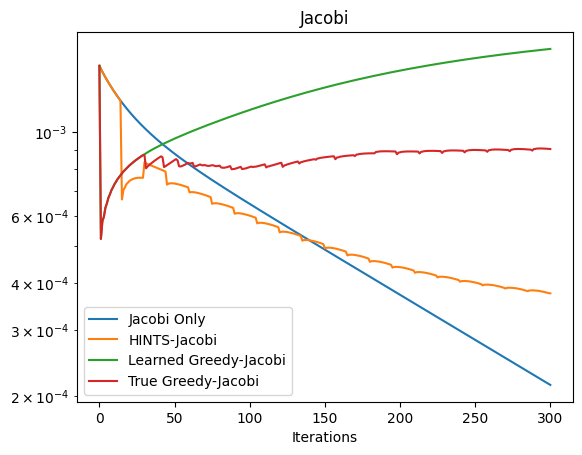

In [18]:
index_of_interest = -1
plt.plot(errors_constant_jacobi[:, index_of_interest], label='Jacobi Only')
plt.plot(errors_hints[:, index_of_interest], label='HINTS-Jacobi')
plt.plot(errors_greedy[:, index_of_interest], label='Learned Greedy-Jacobi')
plt.plot(error_true[:, index_of_interest], label = "True Greedy-Jacobi")
plt.legend()
plt.title("Jacobi")
plt.xlabel("Iterations")
plt.yscale("log")